In [1]:
import numpy as np 
import os
import sys
# from osgeo import gdal, ogr, osr
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
import rioxarray as rxa
sns.set_theme()

from shapely import box
import geopandas as gpd

# ====== import my own functions =========
import sys
import os
scripts_dir = (os.path.dirname(os.getcwd()) + '/scripts/')
sys.path.append(scripts_dir)

from layers import assemble_data
from validation import validate_date_pairs

/bsuhome/julialober/miniforge3/envs/coherence/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data assembly 

Start by identifying the location of the data (there are two inputs required) and the location of the shapefile for the area of interest. 

In [2]:
data_dir = '/bsuhome/julialober/scratch/coherence_data/' # on Borah 
# data_dir = '../data/'# on local machine 

# mcs_aoi = gpd.read_file(data_dir + 'mores_creek.shp')
sample_fp = data_dir + 'uavsar_cohs/mcs/05208/mcs_lowman_05208_200131_200213_coh.nc'
sample = xr.open_dataset(sample_fp)
sample5070 = sample.rio.reproject('EPSG:5070')
# sample
mcs_aoi = box(*sample.rio.bounds())
mcs_5070 = box(*sample5070.rio.bounds())
print(mcs_aoi)
print(mcs_5070)
# print(mcs_aoi)

getfattr: /bsuhome/julialober/scratch/coherence_data/uavsar_cohs/mcs/05208/mcs_lowman_05208_200131_200213_coh.nc: Operation not supported


POLYGON ((-115.63548033331044 43.90718161502215, -115.63548033331044 43.98397534443853, -115.7352319093607 43.98397534443853, -115.7352319093607 43.90718161502215, -115.63548033331044 43.90718161502215))
POLYGON ((-1558403.625175005 2485722.860238994, -1558403.625175005 2495743.9710659473, -1567971.9449963712 2495743.9710659473, -1567971.9449963712 2485722.860238994, -1558403.625175005 2485722.860238994))


I just hard coded the dates for the flights that cover MCS from flight path 05208. These need to match the dates in the filenames of the coherence files. 

In [3]:
mcs_lowman_05208_dates = ['200131_200213',
 '200131_200220',
 '200131_200311',
 '200131_210203',
 '200131_210210',
 '200131_210303',
 '200131_210310',
 '200131_210316',
 '200131_210322',
 '200213_200220',
 '200213_200311',
 '200213_210203',
 '200213_210210',
 '200213_210303',
 '200213_210310',
 '200213_210316',
 '200213_210322',
 '200220_200311',
 '200220_210203',
 '200220_210210',
 '200220_210303',
 '200220_210310',
 '200220_210316',
 '200220_210322',
 '200311_210203',
 '200311_210210',
 '200311_210303',
 '200311_210310',
 '200311_210316',
 '200311_210322',
 '210203_210210',
 '210203_210303',
 '210203_210310',
 '210203_210316',
 '210203_210322',
 '210210_210303',
 '210210_210310',
 '210210_210316',
 '210210_210322',
 '210303_210310',
 '210303_210316',
 '210303_210322',
 '210310_210316',
 '210310_210322',
 '210316_210322']

split_dates = [(part[0], part[1]) for part in [d.split('_') for d in mcs_lowman_05208_dates]]
unique_dates = set([date for pair in split_dates for date in pair])
nearest_pairs = np.array(list(zip(sorted(unique_dates), sorted(unique_dates)[1:])))
nearest_pairs = [pair for pair in nearest_pairs if pair[0][:2] == pair[1][:2]]
nearest_dates = [(f"{pair[0]}_{pair[1]}") for pair in nearest_pairs]


# go from YYMMDD to YYYYMMDD
split_dates = [(f"20{date[0]}", f"20{date[1]}") for date in split_dates]

In [4]:
# clean up multi-year dates 
split_dates_sameyr = [pair for pair in split_dates if pair[0][:4] == pair[1][:4]]
split_dates_sameyr 

[('20200131', '20200213'),
 ('20200131', '20200220'),
 ('20200131', '20200311'),
 ('20200213', '20200220'),
 ('20200213', '20200311'),
 ('20200220', '20200311'),
 ('20210203', '20210210'),
 ('20210203', '20210303'),
 ('20210203', '20210310'),
 ('20210203', '20210316'),
 ('20210203', '20210322'),
 ('20210210', '20210303'),
 ('20210210', '20210310'),
 ('20210210', '20210316'),
 ('20210210', '20210322'),
 ('20210303', '20210310'),
 ('20210303', '20210316'),
 ('20210303', '20210322'),
 ('20210310', '20210316'),
 ('20210310', '20210322'),
 ('20210316', '20210322')]

In [5]:
# aoi = box(*mcs_aoi.total_bounds) # using the total bounds to get some buffer 
# test_dates = [("20200101", "20200113"), 
#          ("20200101", "20200129"),
#          ("20200113", "20200129"),
#          ("20210202", "20210214")]
dates_val = validate_date_pairs(split_dates_sameyr)
fp_out = data_dir + 'stacks/mores_creek'
coh_dir = data_dir + 'uavsar_cohs/mcs'
inc_dir = data_dir + 'inc_angle'
sc_dir = data_dir + 'NSIDC-0768'

This function requires two things be downloaded and ready: 
1. The Snow Climatology from NSIDC 

    filename: `SnowClass_NA_300m_10.0arcsec_2021_v01.0.nc`

2. Geocoded coherence files

    filename: `[...]_YYMMDD_YYMMDD_[...].?`

In [8]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    force=True 
)

data = assemble_data(mcs_aoi,
                    dates_val,
                    ['05208'],
                    fp_out,
                    fp_coh=coh_dir,
                    fp_inc=inc_dir,
                    fp_snowclimate=sc_dir,
                    overwrite = True)
data

2026-04-01 08:48:26,422 - INFO - Starting data assembly for flights ['05208']
getfattr: /bsuhome/julialober/scratch/coherence_data/uavsar_cohs/mcs/05208/mcs_lowman_05208_200131_200213_coh.nc: Operation not supported
getfattr: /bsuhome/julialober/scratch/coherence_data/uavsar_cohs/mcs/05208/mcs_lowman_05208_200131_200220_coh.nc: Operation not supported
getfattr: /bsuhome/julialober/scratch/coherence_data/uavsar_cohs/mcs/05208/mcs_lowman_05208_200131_200311_coh.nc: Operation not supported
getfattr: /bsuhome/julialober/scratch/coherence_data/uavsar_cohs/mcs/05208/mcs_lowman_05208_200213_200220_coh.nc: Operation not supported
getfattr: /bsuhome/julialober/scratch/coherence_data/uavsar_cohs/mcs/05208/mcs_lowman_05208_200213_200311_coh.nc: Operation not supported
getfattr: /bsuhome/julialober/scratch/coherence_data/uavsar_cohs/mcs/05208/mcs_lowman_05208_200220_200311_coh.nc: Operation not supported
getfattr: /bsuhome/julialober/scratch/coherence_data/uavsar_cohs/mcs/05208/mcs_lowman_05208_21

In [6]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    force=True 
)

data = assemble_data(mcs_5070,
                    dates_val,
                    ['05208'],
                    fp_out,
                    fp_coh=coh_dir,
                    fp_inc=inc_dir,
                    fp_snowclimate=sc_dir,
                    crs='EPSG:5070',
                    overwrite = True)
data

2026-04-01 08:45:00,599 - INFO - Starting data assembly for flights ['05208']
getfattr: /bsuhome/julialober/scratch/coherence_data/uavsar_cohs/mcs/05208/mcs_lowman_05208_200131_200213_coh.nc: Operation not supported
getfattr: /bsuhome/julialober/scratch/coherence_data/uavsar_cohs/mcs/05208/mcs_lowman_05208_200131_200220_coh.nc: Operation not supported
getfattr: /bsuhome/julialober/scratch/coherence_data/uavsar_cohs/mcs/05208/mcs_lowman_05208_200131_200311_coh.nc: Operation not supported
getfattr: /bsuhome/julialober/scratch/coherence_data/uavsar_cohs/mcs/05208/mcs_lowman_05208_200213_200220_coh.nc: Operation not supported
getfattr: /bsuhome/julialober/scratch/coherence_data/uavsar_cohs/mcs/05208/mcs_lowman_05208_200213_200311_coh.nc: Operation not supported
getfattr: /bsuhome/julialober/scratch/coherence_data/uavsar_cohs/mcs/05208/mcs_lowman_05208_200220_200311_coh.nc: Operation not supported
getfattr: /bsuhome/julialober/scratch/coherence_data/uavsar_cohs/mcs/05208/mcs_lowman_05208_21

<xarray.Dataset> Size: 291MB
Dimensions:             (flight_id: 1, pair: 21, y: 335, x: 319)
Coordinates:
    band                int64 8B 1
    spatial_ref         int64 8B 0
  * x                   (x) float64 3kB -1.568e+06 -1.568e+06 ... -1.558e+06
  * y                   (y) float64 3kB 2.496e+06 2.496e+06 ... 2.486e+06
  * pair                (pair) <U13 1kB '200131_200213' ... '210316_210322'
  * flight_id           (flight_id) <U5 20B '05208'
    crs                 int64 8B 0
Data variables: (12/26)
    coherence           (flight_id, pair, y, x) float32 9MB nan nan ... nan nan
    incidence_angle     (flight_id, y, x) float64 855kB 64.39 66.26 ... nan nan
    elevation           (y, x) float32 427kB 2.002e+03 2.021e+03 ... nan nan
    slope               (y, x) float32 427kB 35.36 30.01 17.53 ... 31.58 30.96
    aspect              (y, x) float32 427kB 293.3 275.7 269.7 ... 23.0 37.19
    curve               (y, x) float32 427kB -0.0 0.5173 1.219 ... 0.8203 -0.0
    ...                  ...
    total_rain          (pair, y, x) float64 18MB nan nan nan ... 0.0 0.0 0.0
    total_snow          (pair, y, x) float64 18MB nan nan nan ... 0.0 0.0 0.0
    acq_day_precip      (pair, y, x) float64 18MB nan nan nan ... nan nan nan
    hours_blowing_snow  (pair, y, x) float64 18MB nan nan nan ... 0.0 0.0 0.0
    mean_wind           (pair, y, x) float64 18MB nan nan nan ... nan nan nan
    max_wind            (pair, y, x) float64 18MB nan nan nan ... nan nan nan

In [38]:
print(data.pair.values)
print(nearest_dates)

['200131_200213' '200131_200220' '200131_200311' '200213_200220'
 '200213_200311' '200220_200311' '210203_210210' '210203_210303'
 '210203_210310' '210203_210316' '210203_210322' '210210_210303'
 '210210_210310' '210210_210316' '210210_210322' '210303_210310'
 '210303_210316' '210303_210322' '210310_210316' '210310_210322'
 '210316_210322']
['200131_200213', '200213_200220', '200220_200311', '210203_210210', '210210_210303', '210303_210310', '210310_210316', '210316_210322']


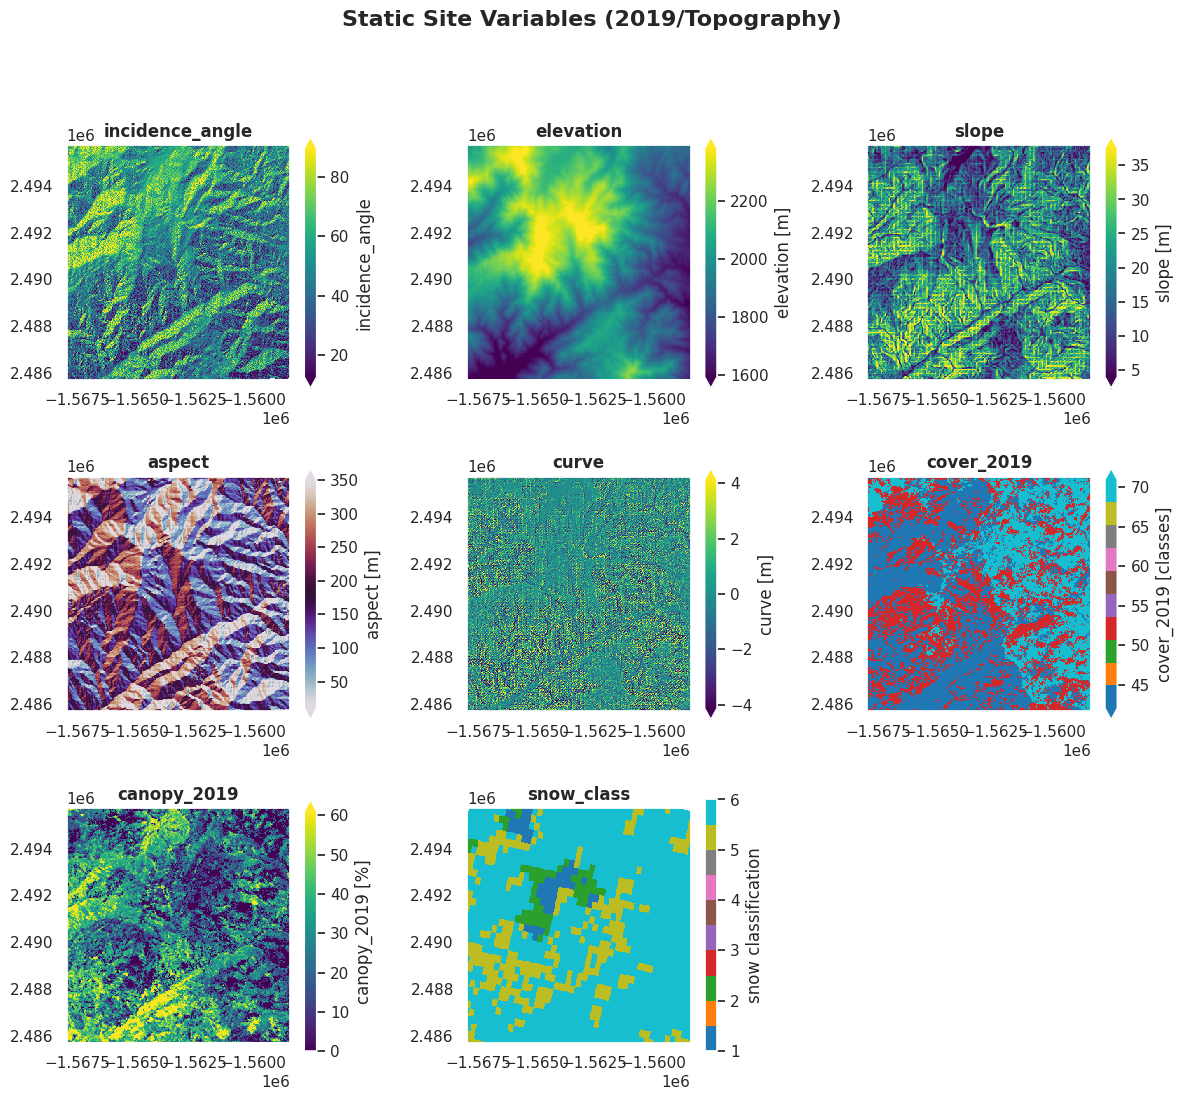

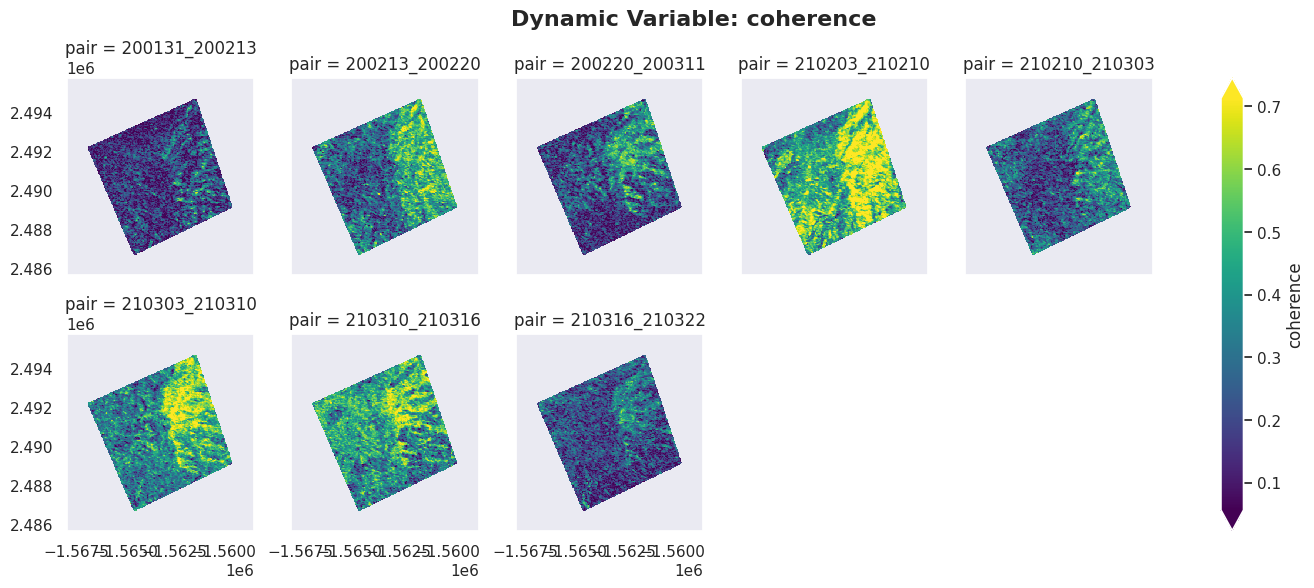

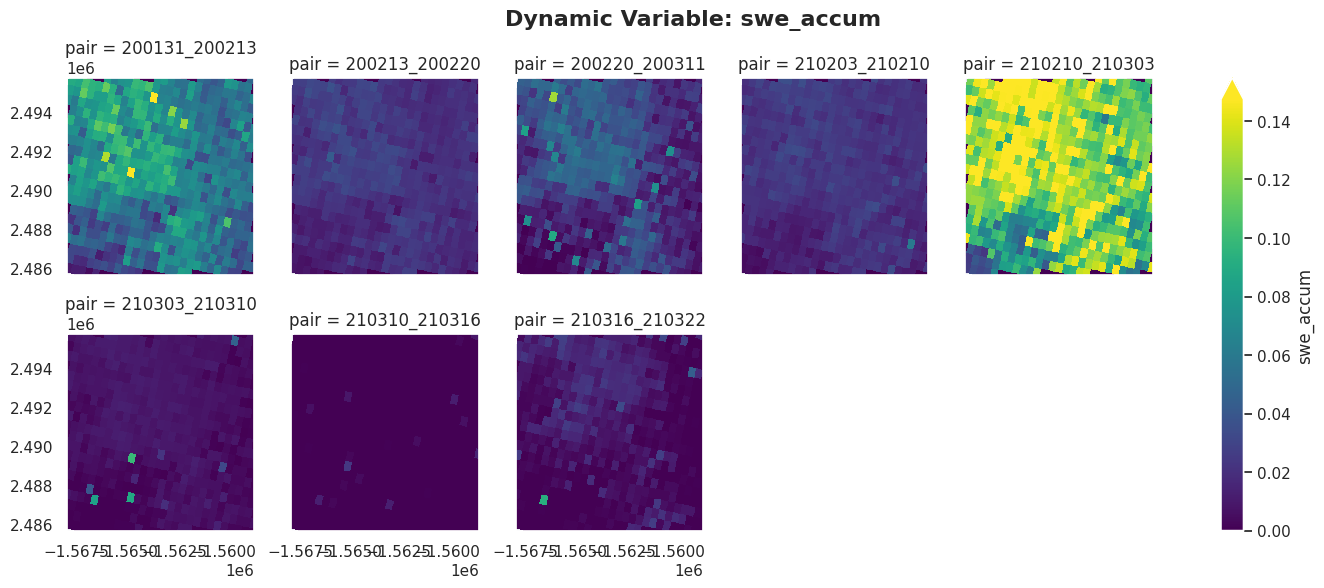

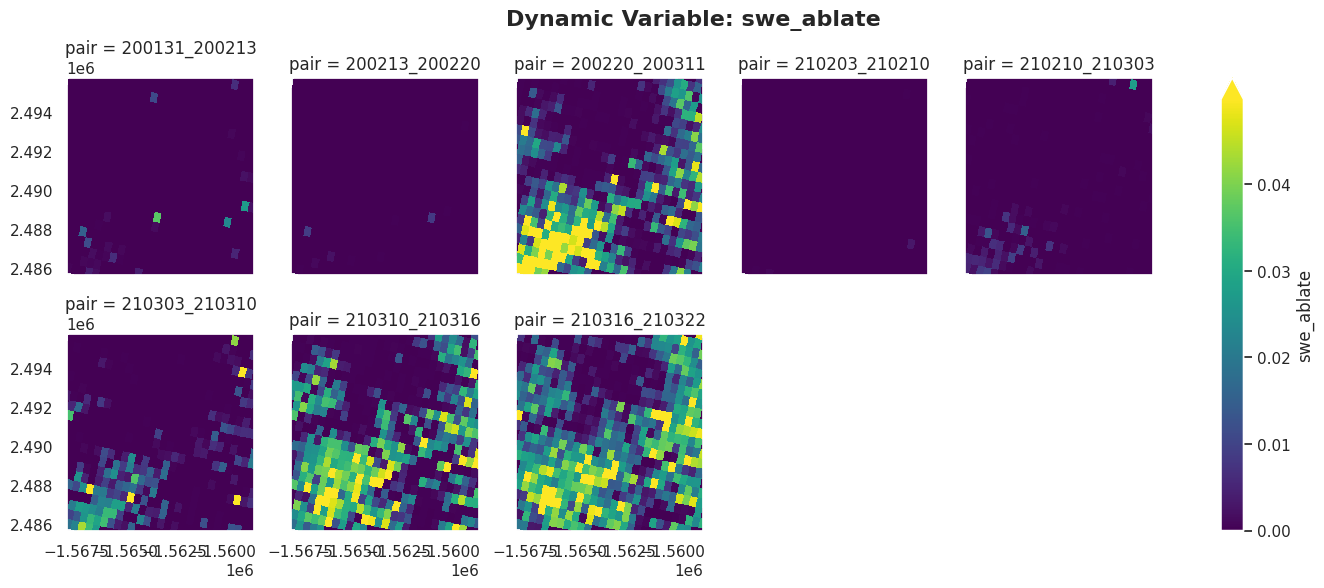

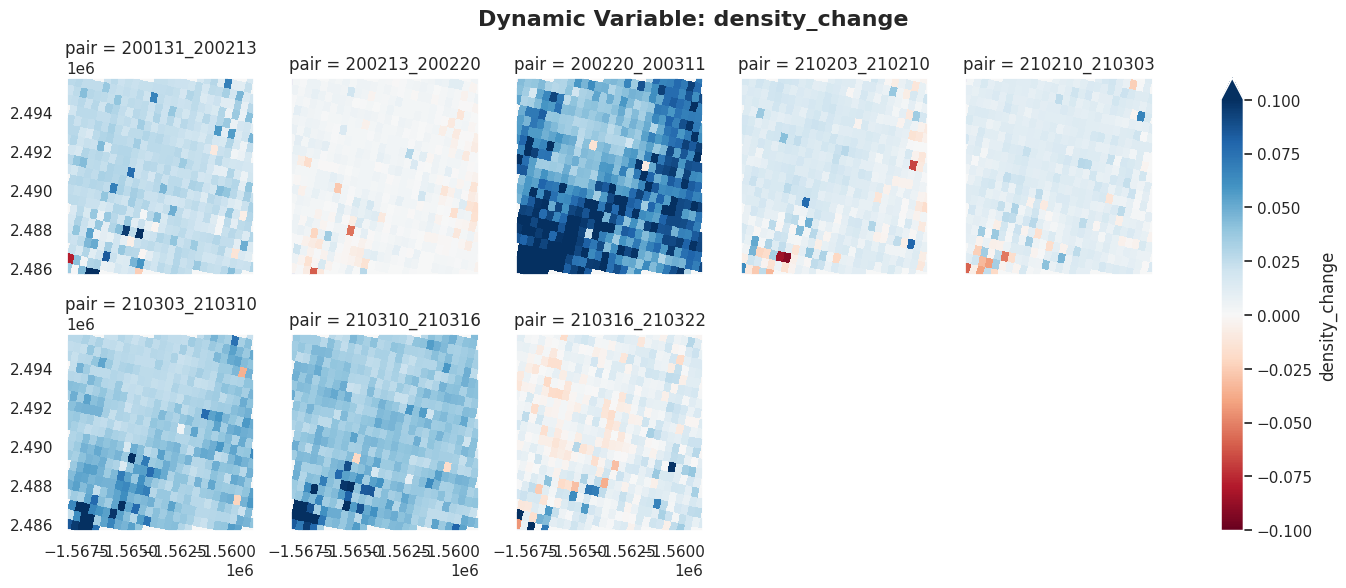

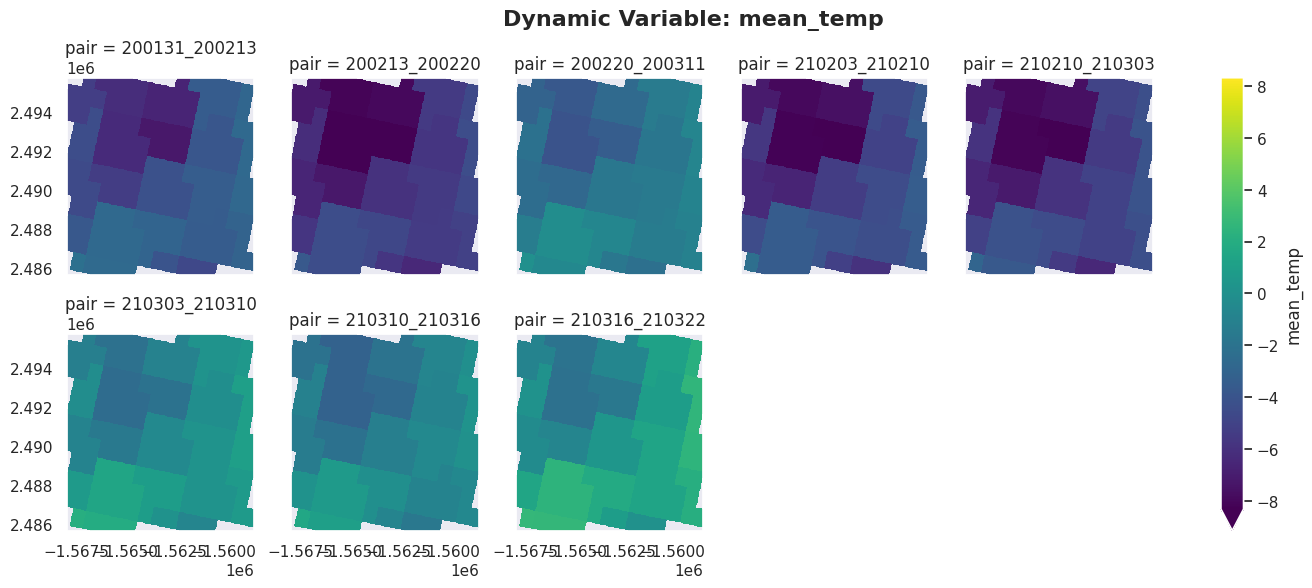

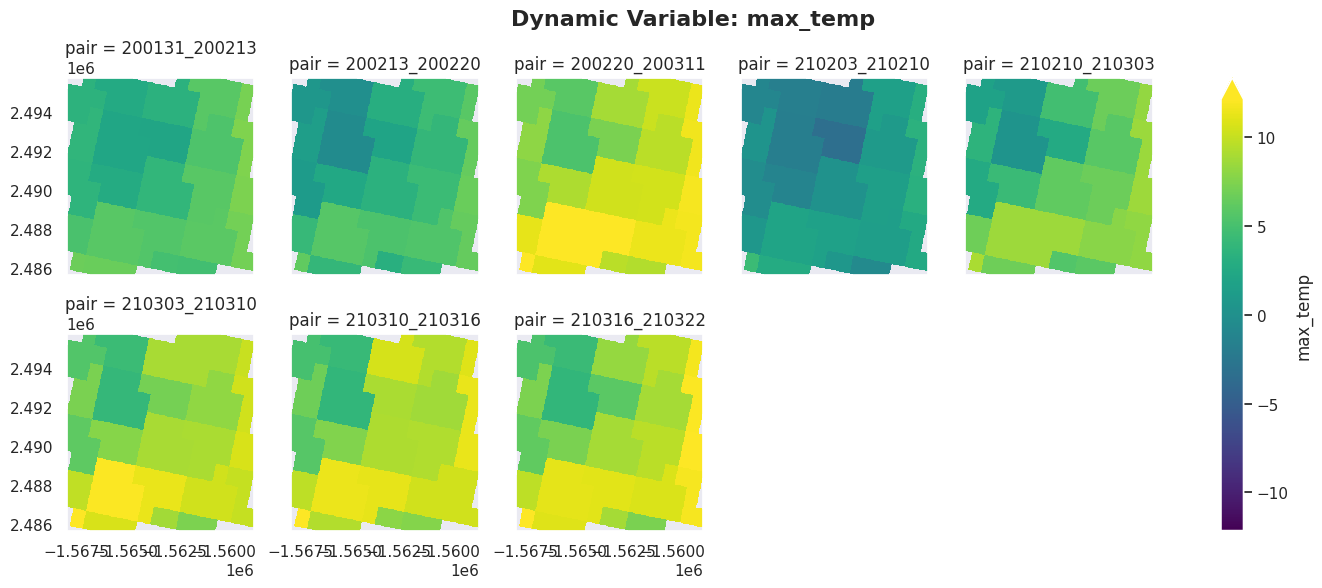

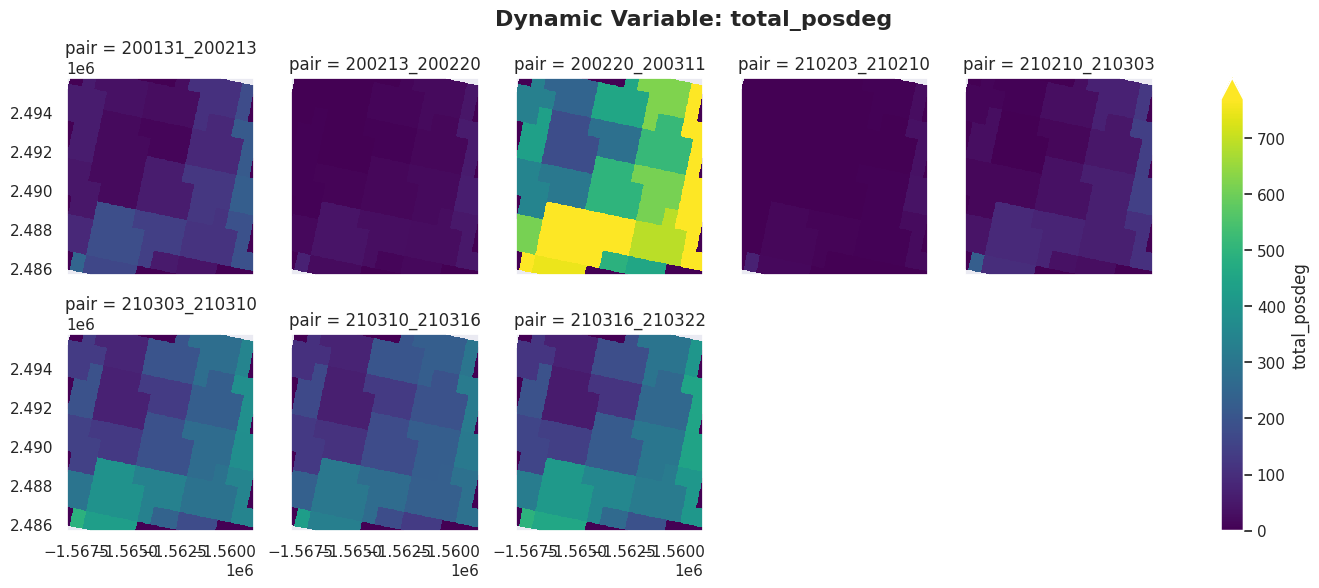

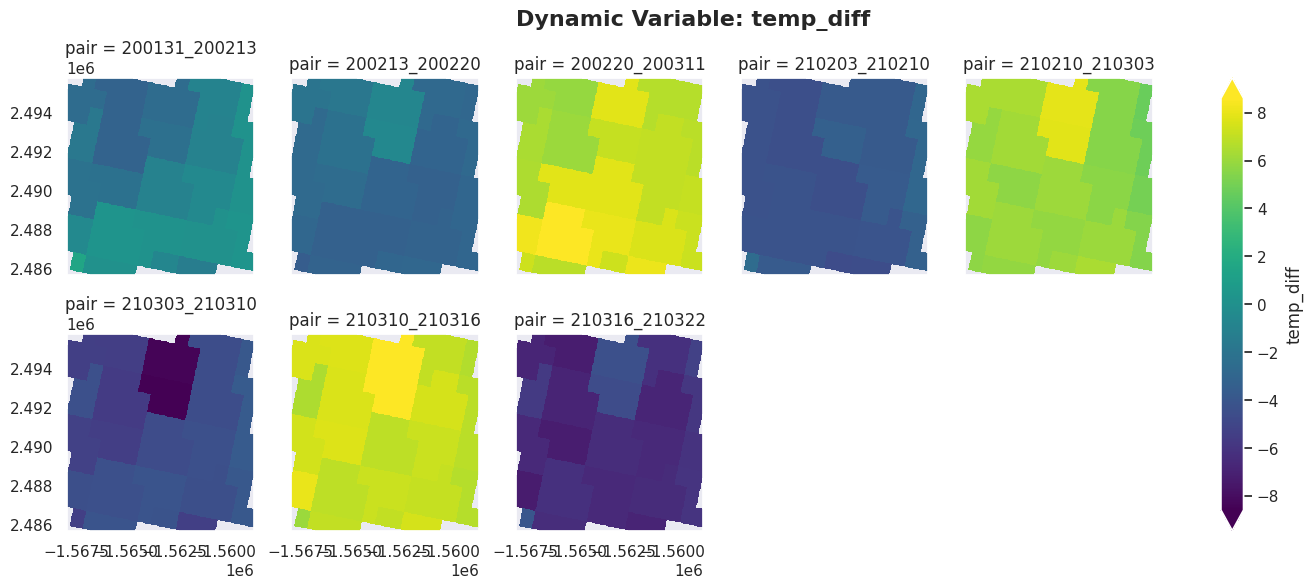

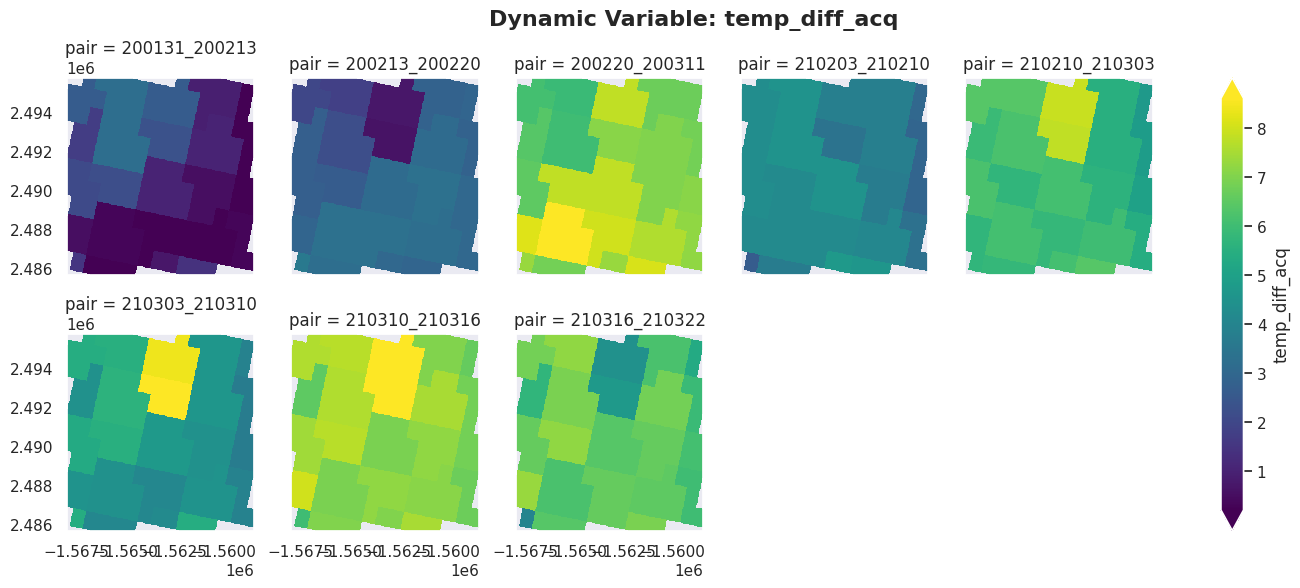

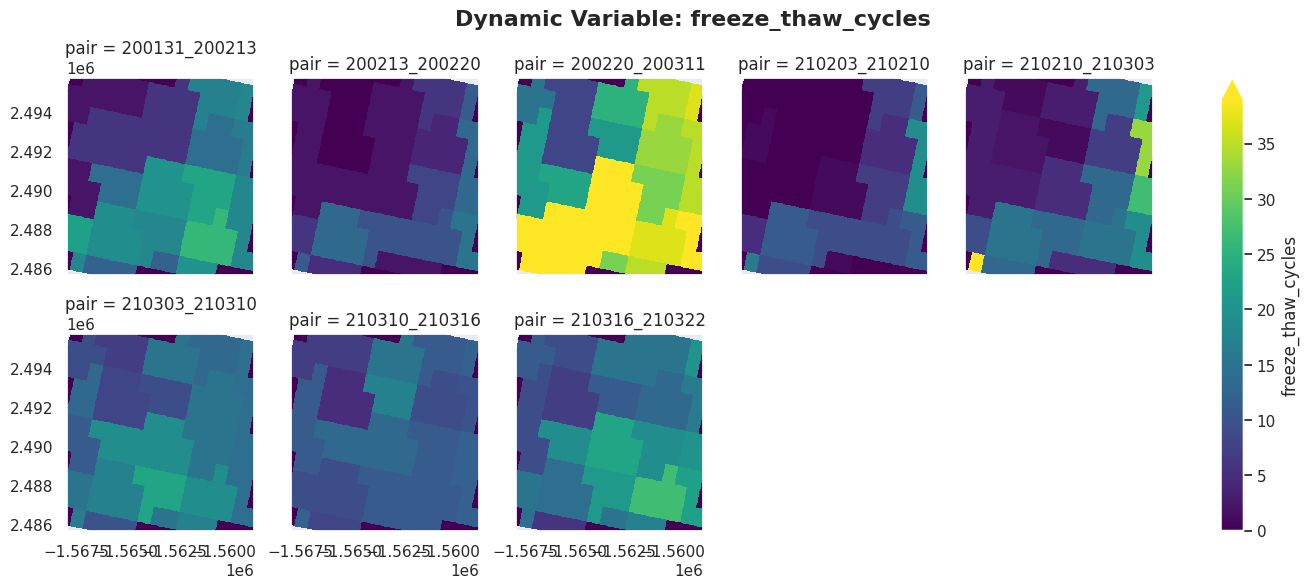

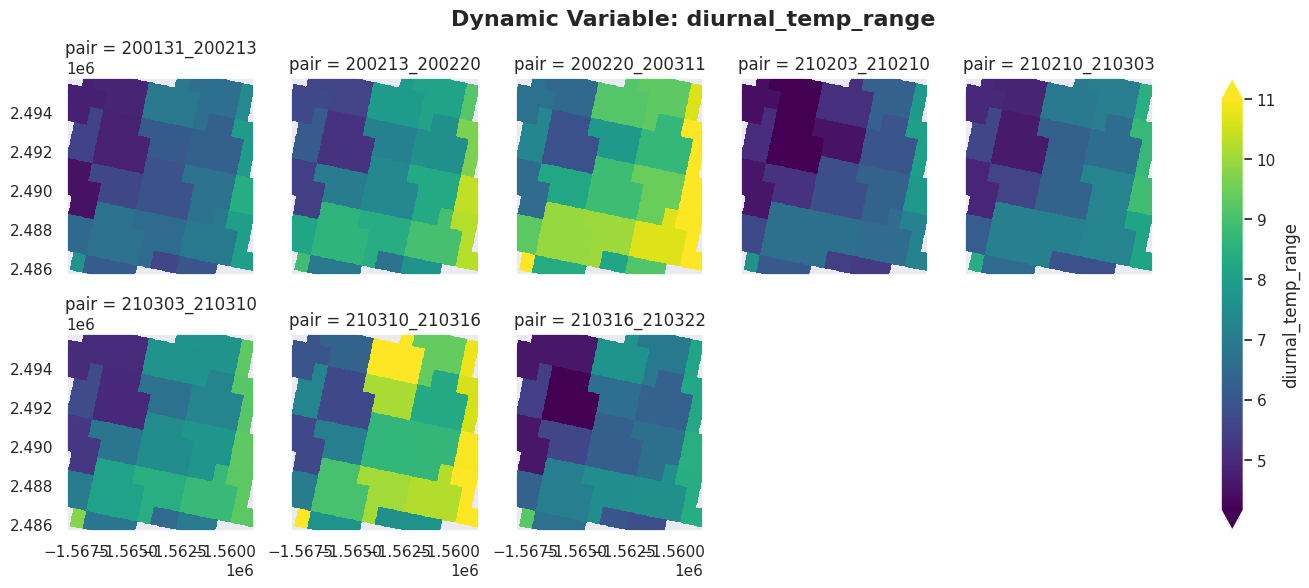

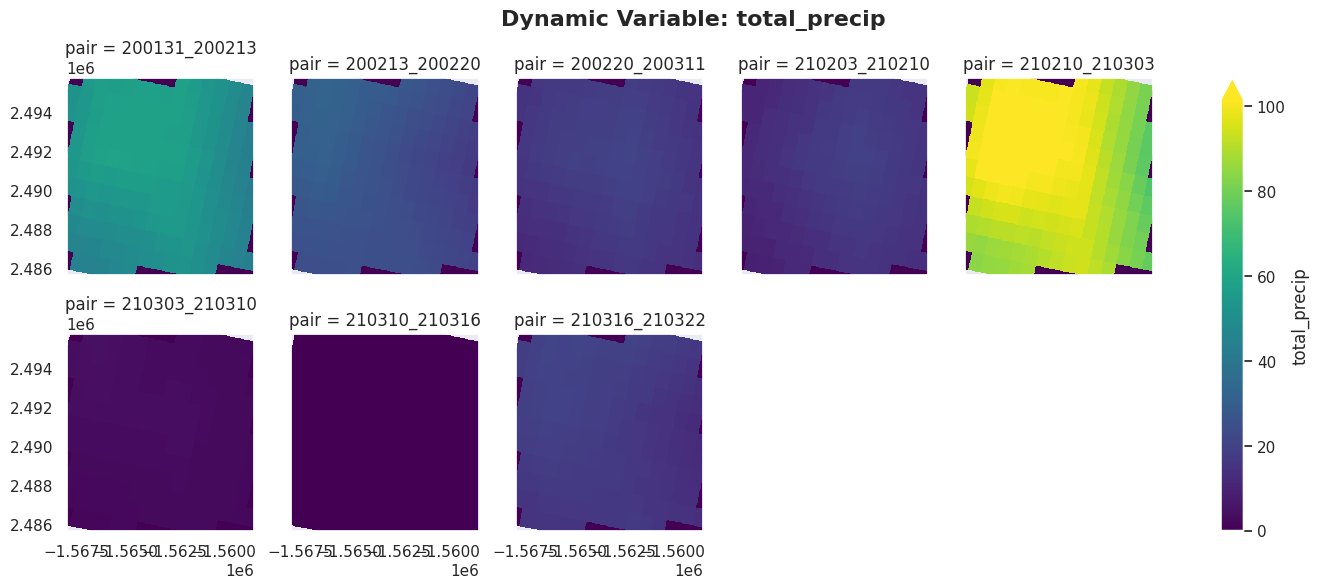

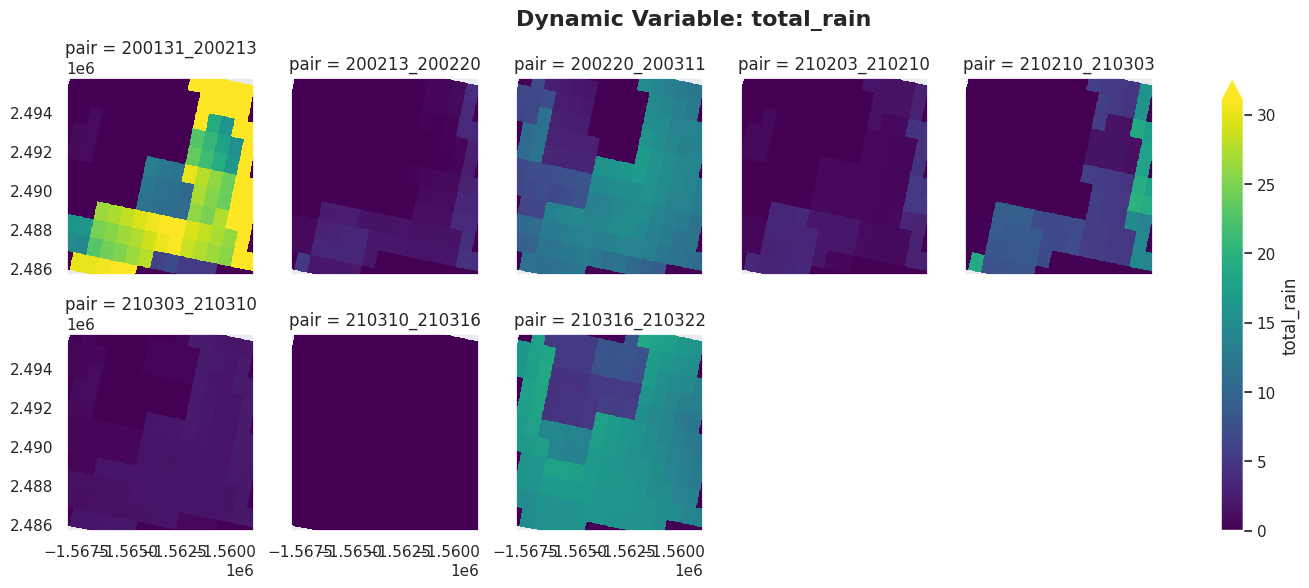

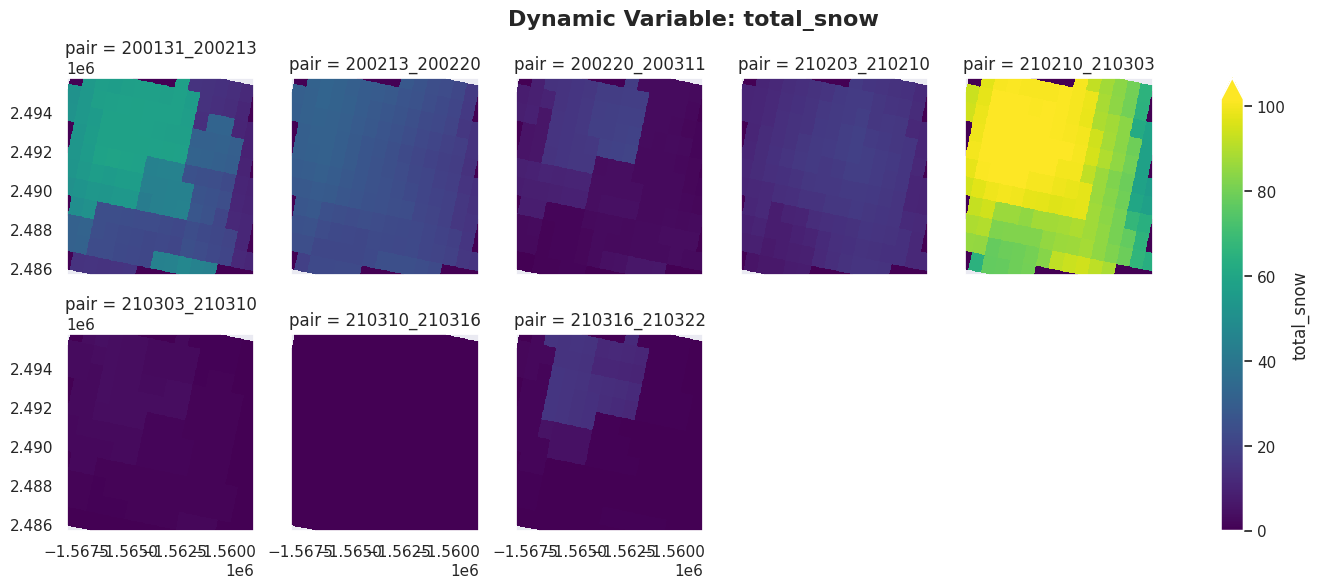

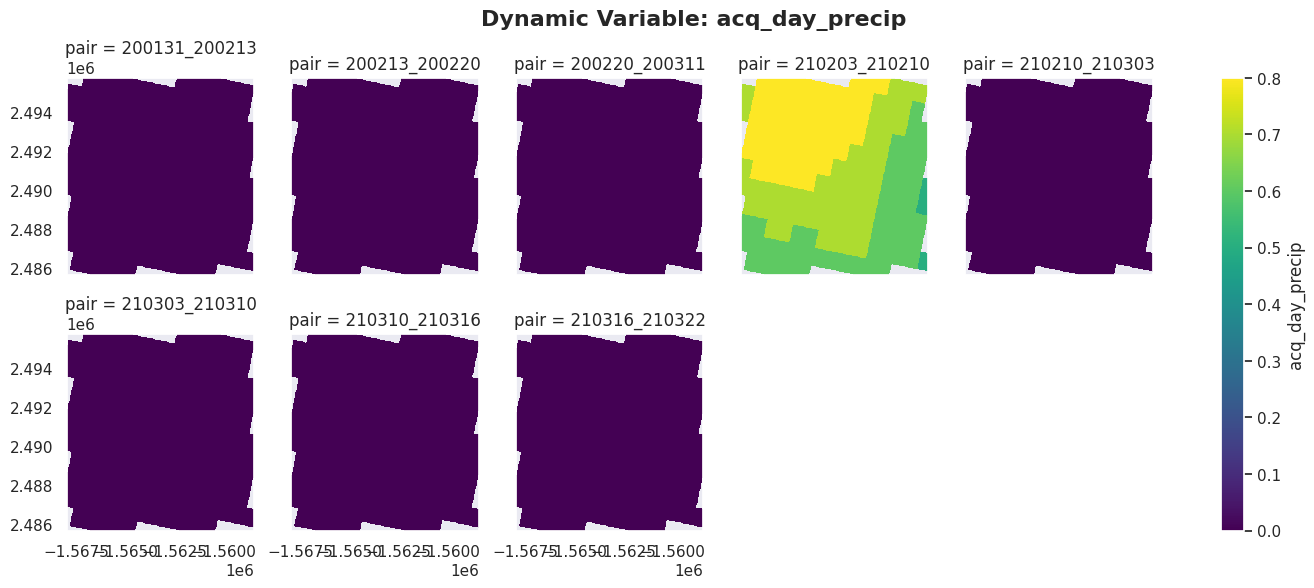

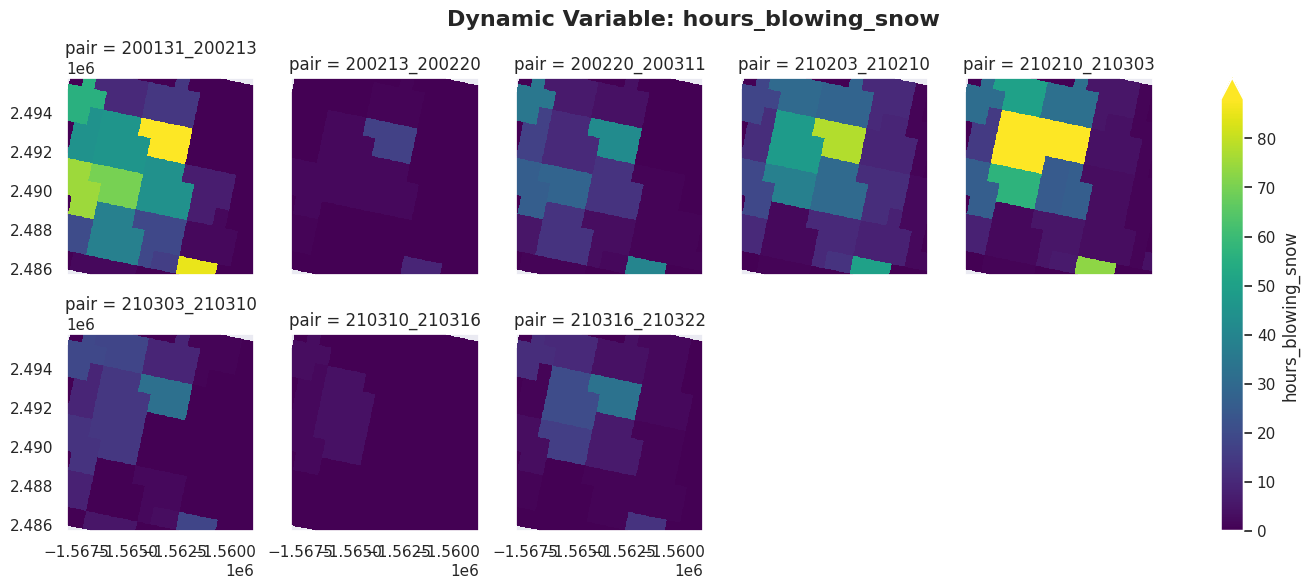

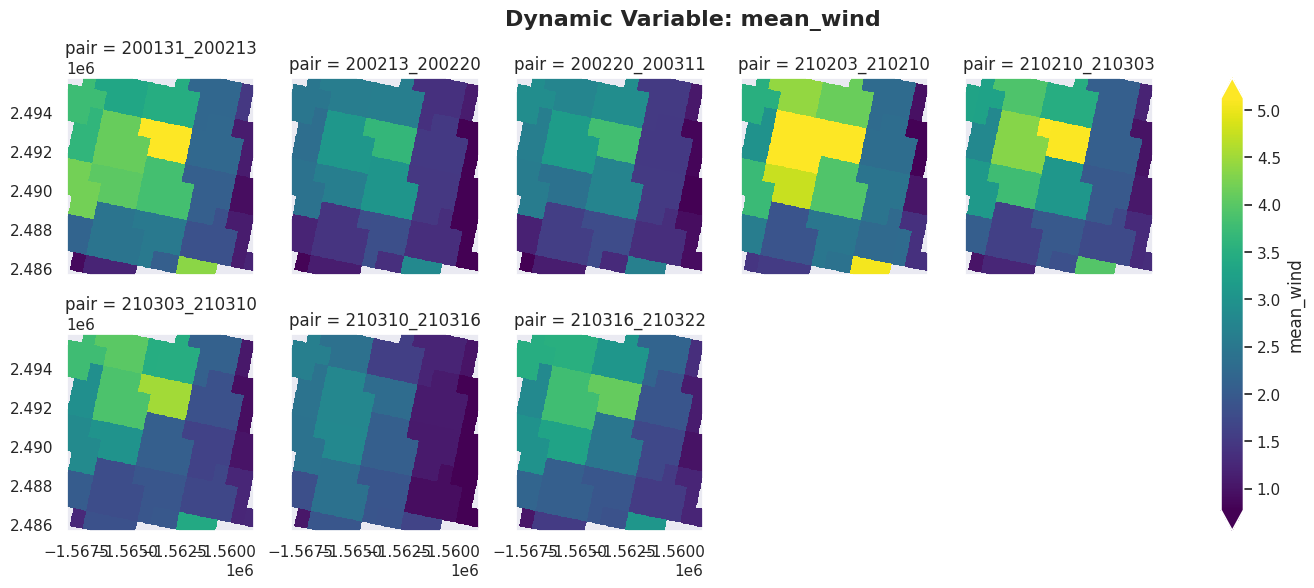

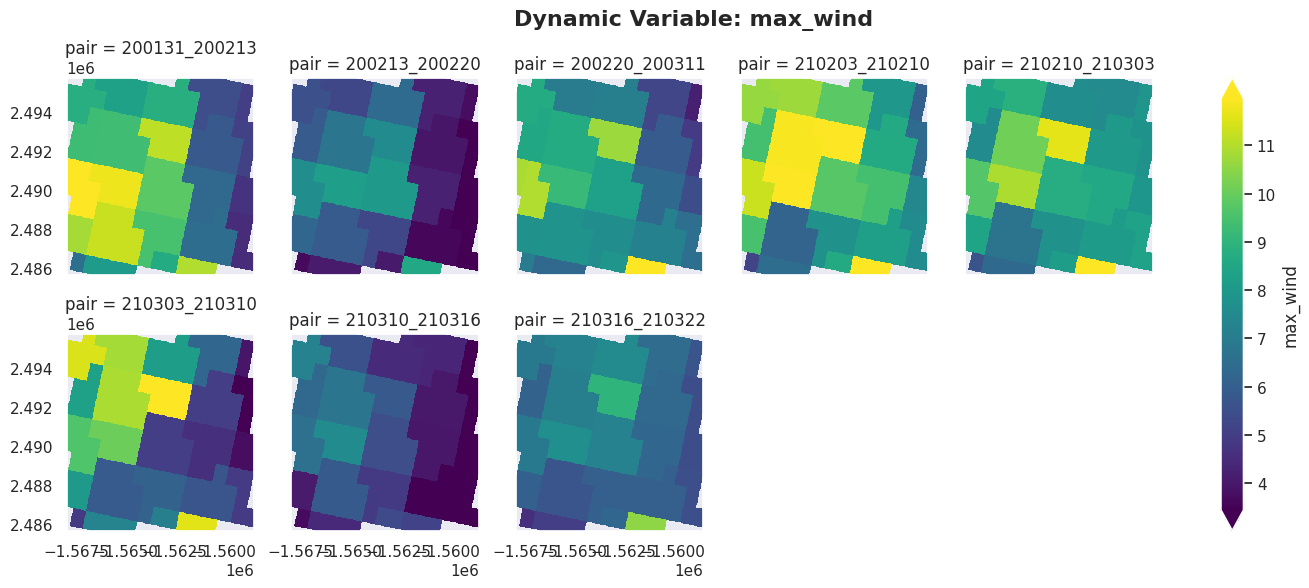

In [ ]:
# plot the variables

# 1. Separate variables into two lists based on their dimensions
static_vars = [var for var in data.data_vars if 'pair' not in data[var].dims]
pair_vars = [var for var in data.data_vars if 'pair' in data[var].dims]

# ==========================================
# 2. PLOT STATIC VARIABLES (Single Dashboard)
# ==========================================
n_static = len(static_vars)
cols = 3
rows = int(np.ceil(n_static / cols))

# Create one figure for all static variables
fig_static, axes_static = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
axes_static = axes_static.flatten()

for i, var in enumerate(static_vars):
    ax = axes_static[i]
    
    if var in 'aspect' : cmap = 'twilight'  # cyclic colormap for aspect
    elif var in ['snow_class', 'cover_2019']: cmap = 'tab10'  # categorical colormap for classes
    else: cmap = 'viridis'  # standard colormap for other variables

    # robust=True drops top/bottom 2% of extreme values for a prettier color stretch
    data[var].plot(ax=ax, robust=True, cmap=cmap) 

    
    ax.set_title(var, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_aspect('equal') # Keeps pixels square since this is spatial data

# Hide any empty subplots if n_static doesn't divide perfectly by 3
for j in range(i + 1, len(axes_static)):
    axes_static[j].set_visible(False)

fig_static.suptitle('Static Site Variables (2019/Topography)', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


# ==========================================
# 3. PLOT DYNAMIC VARIABLES (One Figure Each)
# ==========================================
for var in pair_vars:
    # Pick a diverging colormap for 'change' variables, standard for others
    cmap = 'RdBu' if 'change' in var else 'viridis'
    
    # Xarray automatically creates a multi-panel figure when you use col=
    # plot only nearest_dates
    fg = data[var].sel(pair=nearest_dates).plot(
        col='pair',
        col_wrap=5,  # 5 plots per row looks nice for 45 pairs
        figsize=(15, 3 * int(np.ceil(len(nearest_dates) / 5))),
        robust=True,
        cmap=cmap
    )

    # fg = data[var].plot(
    #     col='pair',
    #     col_wrap=5,  # 5 plots per row looks nice for 45 pairs
    #     figsize=(15, 3 * int(np.ceil(data.sizes['pair'] / 5))),
    #     robust=True,
    #     cmap=cmap
    # )
    
    # Add a main title for this specific variable's figure
    fg.fig.suptitle(f'Dynamic Variable: {var}', fontsize=16, fontweight='bold', y=1.02)
    
    # Clean up the individual axes
    for ax in fg.axs.flat:
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_aspect('equal')
        
    plt.show()